In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

1. Create a container
2. First layer to remember things in a sequence
3. Second layer to make decisions
4. Third layer (Dense layer) to decide what to do with previous decisions
5. Dropout Layer: Let half of the helpers rest to avoid mistakes
6. Final Dense Layer for output
7. Check the model summary
8. Compile

In [ ]:
# Read csv file
data = pd.read_csv('/content/drive/MyDrive/Projects/LSTM/MicrosoftStock.csv')

In [ ]:
data.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB


In [ ]:
data.describe()

,index,open,high,low,close,volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,390827.000000,51.026394,51.436007,50.630397,51.063081,3.386946e+07
std,363.586303,14.859387,14.930144,14.774630,14.852117,1.958979e+07
min,390198.000000,27.350000,27.600000,27.230000,27.370000,7.425603e+06
25%,390512.500000,40.305000,40.637500,39.870000,40.310000,2.254879e+07
50%,390827.000000,47.440000,47.810000,47.005000,47.520000,2.938758e+07
75%,391141.500000,59.955000,60.435000,59.275000,59.730000,3.842024e+07
max,391456.000000,95.140000,96.070000,93.720000,95.010000,2.483542e+08


Initial Data Visualization


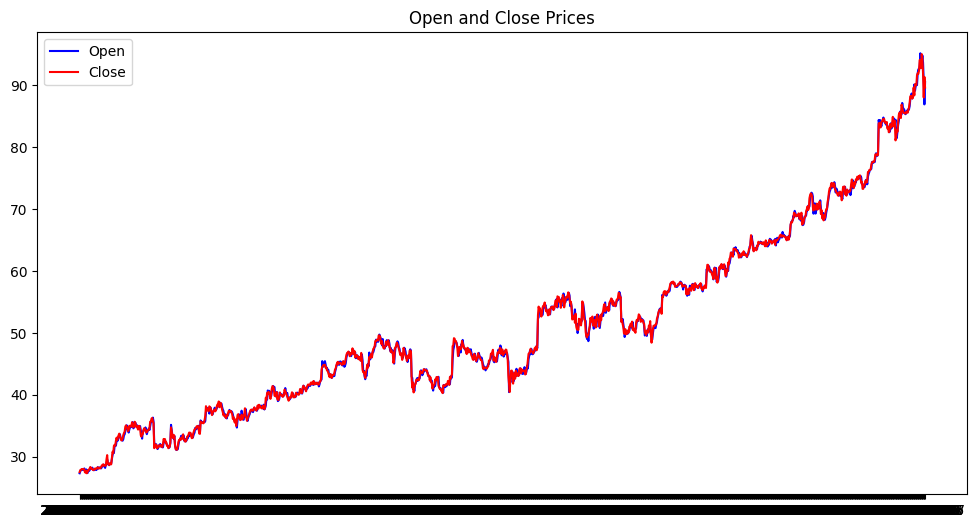

In [ ]:
# Open and Close prices of time
plt.figure(figsize=(12,6))
plt.plot(data['date'],data['open'],label='Open',color='blue')
plt.plot(data['date'],data['close'],label='Close',color='red')
plt.title('Open and Close Prices')
plt.legend()
plt.show()

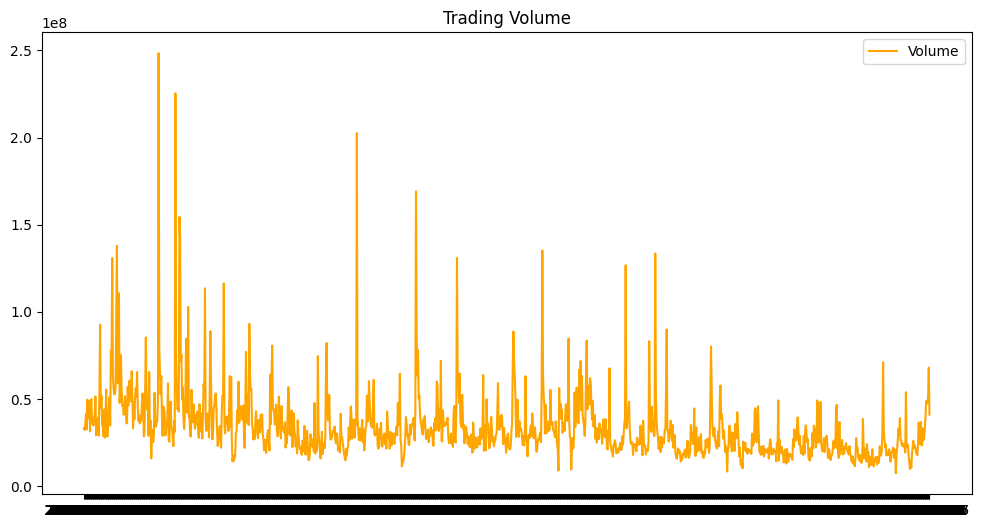

In [ ]:
# Trading vol
plt.figure(figsize=(12,6))
plt.plot(data['date'],data['volume'],label='Volume',color='orange')
plt.title('Trading Volume')
plt.legend()
plt.show()

In [ ]:
# Drop non numeric columns
numeric_data = data.select_dtypes(include=['int64','float64'])

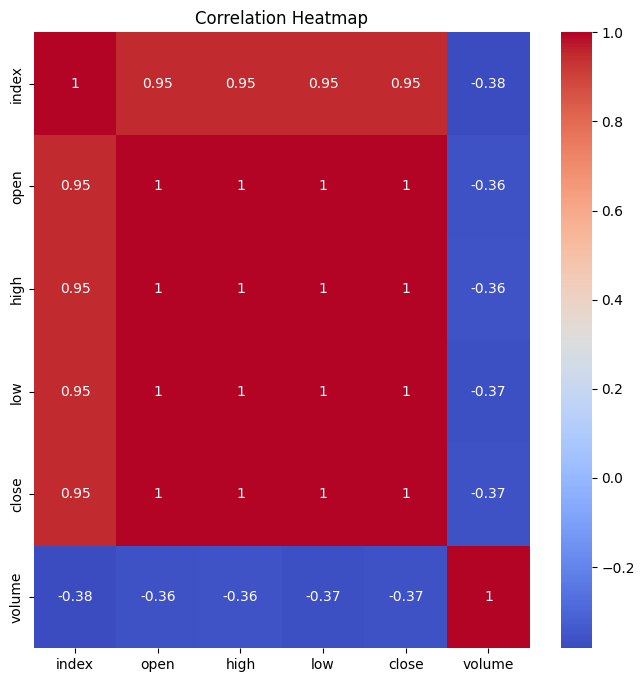

In [ ]:
# Check for correlation between features
plt.figure(figsize=(8,8))
sns.heatmap(numeric_data.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Convert the data into date time and create a date filter

data['date'] = pd.to_datetime(data['date'])

In [ ]:
prediction = data.loc[
    (data['date'] > datetime(2013,1,1)) &
    (data['date'] < datetime(2018,1,1))
]

/tmp/ipython-input-2912865148.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


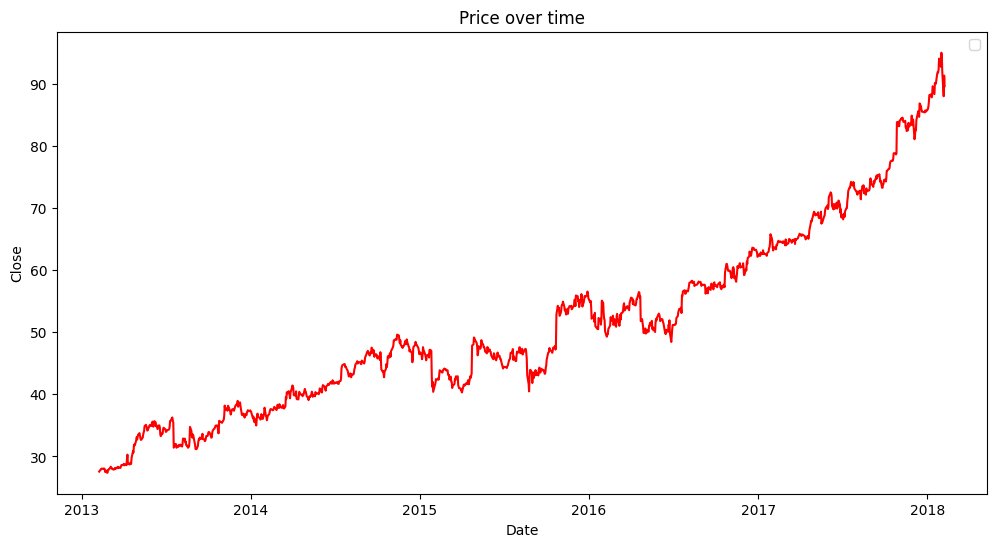

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data['date'],data['close'],color='red')
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Price over time')
plt.legend()
#plt.show()

In [ ]:
# Prepare for the LSTM Model
stock_close = data.filter(['close']) # converts close to 2D array

In [ ]:
# Convert to numpy array
dataset = stock_close.values

In [ ]:
dataset

array([[27.55],
       [27.86],
       [27.88],
       ...,
       [88.  ],
       [91.33],
       [89.61]])

In [ ]:
# Length of training set 95% of data
training_data_len = int(np.ceil(len(dataset)*0.95))

In [ ]:
# Preprocessing
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

In [ ]:
# Make the training data
training_data = scaled_data[:training_data_len]

In [ ]:
X_train,y_train = [] , []

In [ ]:
# Create a sliding window for the stock (60 days)
for i in range(60, len(training_data)):
  X_train.append(training_data[i-60:i, 0])
  y_train.append(training_data[i,0])

In [ ]:
# Convert the training data from lists to array for tensor flow
X_train,y_train = np.array(X_train), np.array(y_train)

In [ ]:
# Reshape to 3D array so tensor flow and interpret them better
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))

In [ ]:
# Build the model
model = keras.models.Sequential()

In [ ]:
# First Layer
model.add(keras.layers.LSTM(64,return_sequences=True,input_shape=(X_train.shape[1],1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Second Layer
model.add(keras.layers.LSTM(64,return_sequences=False))

In [ ]:
# Third Layer Dense Layer
model.add(keras.layers.Dense(128,activation='relu'))

In [ ]:
# Fourth Layer (Dropout layer to prevent overfitting)
model.add(keras.layers.Dropout(0.5))

In [ ]:
# Final layer
model.add(keras.layers.Dense(1))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

In [ ]:
# Training
training = model.fit(X_train,y_train,epochs=20,batch_size=32)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.3359 - root_mean_squared_error: 0.4564
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step - loss: 0.1317 - root_mean_squared_error: 0.1757
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.1201 - root_mean_squared_error: 0.1684
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.1158 - root_mean_squared_error: 0.1597
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.1183 - root_mean_squared_error: 0.1610
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.1138 - root_mean_squared_error: 0.1540
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.1081 - root_mean_squared_error: 0.1471
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.1020 - root_mean_squared_error: 0.1372
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.1040 - root_mean_squared_error: 0.1406
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.1057 - root_mean_squared_error: 0.14

In [ ]:
# Prep the test data
test_data = scaled_data[training_data_len - 60:]
X_test,y_test = [] , dataset[training_data_len:]

In [ ]:
# Create test sequences with same window approach
for i in range(60 , len(test_data)):
  X_test.append(test_data[i-60:i,0])

In [ ]:
# Convert X_test into numpy array
X_test = np.array(X_test)
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [ ]:
# Make a prediction
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 450ms/step


In [ ]:
# Plotting Data
train = data[:training_data_len]
test = data[training_data_len:]

In [ ]:
test = test.copy()

In [ ]:
test['Predictions'] = predictions

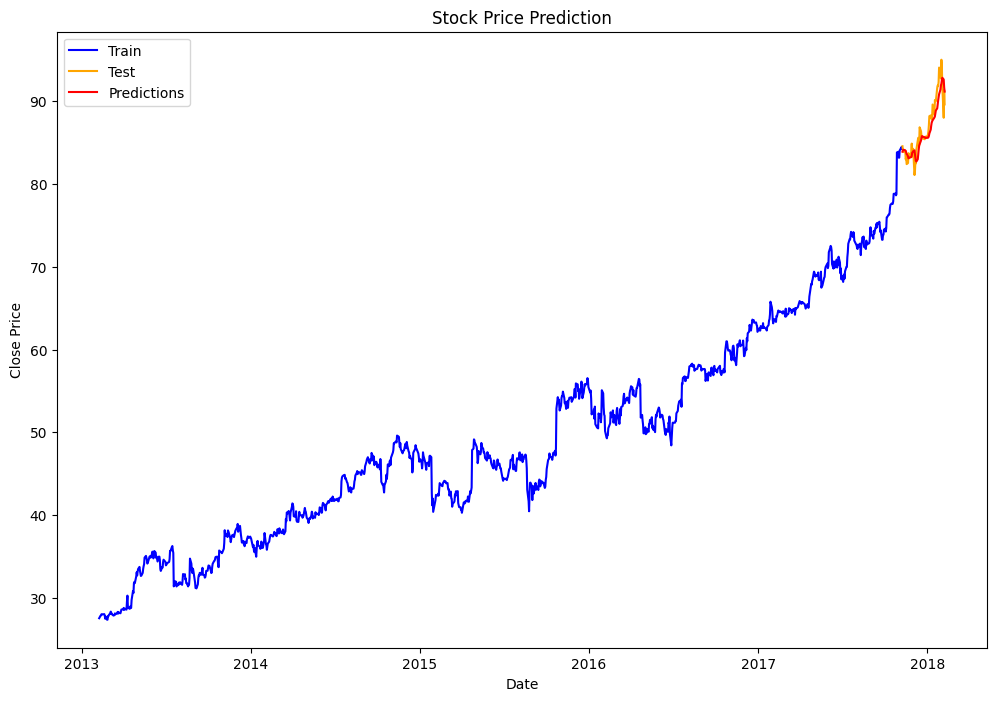

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(train['date'],train['close'],label='Train',color='blue')
plt.plot(test['date'],test['close'],label='Test',color='orange')
plt.plot(test['date'],test['Predictions'],label='Predictions',color='red')
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [ ]:
# === Model Accuracy Evaluation ===
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Extract true values and predictions
y_true = test['close'].values
y_pred = test['Predictions'].values

# Calculate evaluation metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


Model Performance Metrics:
Mean Absolute Error (MAE): 1.1011
Root Mean Squared Error (RMSE): 1.4679
R² Score: 0.8271
